# Descripcion del Dataset

## Vista General

El dataset contiene ventas de propiedades residenciales en Miami / Sur de Florida. Tu objetivo es predecir el **precio de venta** de cada propiedad usando features estructurados, fotos del listado y descripciones de texto.

La division train/test esta predefinida. Entrenas con `train_processed.csv` (con precios conocidos) y predices sobre `test_processed.csv` (precios ocultos).

---

## Archivos

```
participant/
├── data/
│   ├── tabular/
│   │   ├── train_processed.csv    (11,840 filas — features + target)
│   │   └── test_processed.csv     (5,038 filas — solo features, sin target)
│   ├── images/
│   │   └── zillow/                (398K fotos de propiedades, JPG/PNG)
│   ├── train_photo_metadata.csv   (151K filas — mapea zpid → archivos de imagen)
│   └── test_photo_metadata.csv    (64K filas)
├── submissions/
│   ├── template.csv               (zpid + predicted_price = 0)
│   └── purerandom_01..04.csv      (ejemplo: predicciones aleatorias)
├── scripts/                       (scripts de inicio de ejemplo)
└── docs/                          (este archivo + reglas del juego)
```

---

## Tabular Features

### Identificador

| Column | Descripcion |
|--------|-------------|
| `zpid` | ID unico de la propiedad (Zillow). Usalo para unir datos tabulares con metadata de fotos y para enviar predicciones. |

### Target (solo train)

| Column | Descripcion |
|--------|-------------|
| `lastSoldPrice_hpi_adjusted` | Precio de venta ajustado por el Housing Price Index (dolares). Esto es lo que predices. |
| `log_price` | `log1p(lastSoldPrice_hpi_adjusted)` — se recomienda entrenar en escala logaritmica. Convierte de vuelta con `np.expm1()`. |

### Core Property Features

| Column | Type | Descripcion |
|--------|------|-------------|
| `bedrooms` | int | Numero de habitaciones |
| `bathrooms` | float | Numero de banos (incluye medio-banos como 0.5) |
| `livingArea` | float | Area habitable en pies cuadrados |
| `yearBuilt` | float | Ano de construccion de la propiedad |
| `latitude` | float | Latitud de la propiedad |
| `longitude` | float | Longitud de la propiedad |
| `lotAreaValue` | float | Tamano del lote en pies cuadrados |
| `photoCount` | int | Numero de fotos del listado |
| `homeType` | category | SINGLE_FAMILY, CONDO, TOWNHOUSE, MULTI_FAMILY, etc. |
| `zipcode` | category | Codigo postal de 5 digitos |

### Tax & Financial

| Column | Type | Descripcion |
|--------|------|-------------|
| `taxAssessedValue` | float | Valor catastral del condado |
| `propertyTaxRate` | float | Tasa efectiva de impuesto a la propiedad |
| `latest_tax_value` | float | Evaluacion fiscal mas reciente |
| `latest_tax_paid` | float | Pago de impuestos mas reciente |
| `num_tax_records` | int | Numero de registros fiscales historicos |
| `last_listing_price` | float | Precio de listado mas reciente |

### Transaction History

| Column | Type | Descripcion |
|--------|------|-------------|
| `num_sales` | int | Numero de ventas previas |
| `num_price_changes` | int | Numero de cambios de precio en el listado |

### Schools

| Column | Type | Descripcion |
|--------|------|-------------|
| `avg_school_rating` | float | Calificacion promedio de escuelas cercanas (1-10) |
| `max_school_rating` | float | Mejor calificacion de escuela cercana |
| `num_nearby_schools` | int | Cantidad de escuelas cercanas |
| `min_school_distance` | float | Distancia a la escuela mas cercana (millas) |

### Property Attributes

| Column | Type | Descripcion |
|--------|------|-------------|
| `has_hoa` | bool | Tiene asociacion de propietarios |
| `hoa_fee_monthly` | float | Cuota mensual de HOA (0 si no tiene) |
| `has_pool` | bool | La propiedad tiene piscina |
| `has_garage` | bool | La propiedad tiene garage |
| `has_waterfront` | bool | Propiedad frente al agua |

### Listing Tags

| Column | Type | Descripcion |
|--------|------|-------------|
| `tag_price_cut` | bool | Listado con reduccion de precio |
| `tag_new_construction` | bool | Construccion nueva |
| `tag_foreclosure` | bool | Ejecucion hipotecaria o propiedad bancaria |

### Derived Features (pre-calculados)

| Column | Type | Descripcion |
|--------|------|-------------|
| `property_age` | float | 2024 - yearBuilt |
| `bath_to_bed_ratio` | float | bathrooms / bedrooms |
| `log_living_area` | float | log1p(livingArea) |
| `log_lot_area` | float | log1p(lotAreaValue) |
| `zip_3digit` | category | Primeros 3 digitos del ZIP (agrupacion regional) |

### Text Features (pre-calculados desde `description`)

| Column | Type | Descripcion |
|--------|------|-------------|
| `description` | text | Descripcion completa del listado (texto libre). ~52% son plantillas genericas. |
| `desc_length` | int | Conteo de caracteres |
| `desc_word_count` | int | Conteo de palabras |
| `desc_is_boilerplate` | bool | Coincide con patron generico "This X square foot" |
| `desc_mentions_renovated` | bool | La descripcion menciona renovacion |
| `desc_mentions_pool` | bool | La descripcion menciona piscina |
| `desc_mentions_view` | bool | La descripcion menciona vista |
| `desc_mentions_new` | bool | La descripcion menciona "new" |

---

## Photo Metadata

Cada fila en `train_photo_metadata.csv` / `test_photo_metadata.csv` mapea una propiedad a una de sus fotos del listado.

| Column | Descripcion |
|--------|-------------|
| `zpid` | ID de propiedad (clave de union con datos tabulares) |
| `filename` | Nombre del archivo de imagen (ej. `82121262_007.jpg`) |
| `image_index` | Orden de la foto para esta propiedad (0 = foto principal) |
| `image_path` | Ruta relativa desde participant/ al archivo de imagen |
| `address`, `city`, `state` | Ubicacion de la propiedad |
| `bedrooms`, `bathrooms`, `homeType`, `yearBuilt` | Features basicos (duplicados de tabular por conveniencia) |

**Consejos:**
- Las propiedades tienen 1-30+ fotos. Empieza con `image_index == 0` (foto principal).
- Enfoques multi-imagen: extrae embeddings por imagen, luego mean-pool por propiedad.
- Las imagenes son las fotos reales del listado — exteriores, interiores, aereas, planos.

---

## Formato de Envio

Tu CSV de envio debe tener exactamente dos columnas:

```csv
zpid,predicted_price
46753729,450000.00
43855058,280000.00
...
```

- `zpid`: debe coincidir con el test set (5,038 filas)
- `predicted_price`: tu precio de venta predicho en dolares (no transformado con logaritmo)

Sube tu CSV a traves del dashboard de la competencia. Selecciona la ronda para la cual estas enviando — el dashboard valida tu archivo al subirlo.

---

## Consejos

1. **Entrena en log-price**: `log1p(price)` estabiliza el aprendizaje en el amplio rango de precios ($50K-$2M). Convierte de vuelta con `np.expm1()` para envios.

2. **Empieza simple**: Un LightGBM basico con 10 features tabulares da ~29% MAPE. Agrega features iterativamente.

3. **Las imagenes agregan senal**: Embeddings de CNN pre-entrenadas (ResNet, CLIP) capturan calidad visual, vecindario y tipo de propiedad. No entrenes una CNN desde cero — extrae features congelados.

4. **El texto es ruidoso**: ~52% de las descripciones son plantillas genericas. TF-IDF + SVD es un buen baseline. Embeddings de transformers (DistilBERT) pueden ayudar pero son mas dificiles de hacer bien.

5. **Ensambla con cuidado**: Combinar modalidades funciona mejor cuando cada una agrega senal unica. Usa predicciones out-of-fold (OOF) para stacking correcto.

6. **Cuidado con el leakage**: `taxAssessedValue` y `last_listing_price` correlacionan fuertemente con el precio de venta. Usarlos esta permitido pero puedes aprender menos.

7. **Mejora por ronda**: Envias predicciones por ronda via el dashboard. Usa las primeras rondas para probar modelos simples, mejora para rondas posteriores. La competencia hace forward-fill: si solo envias la ronda 1, se usa para todas las rondas posteriores tambien. Cada ronda evalua sobre un pool diferente de propiedades, asi que no puedes sobreajustar al feedback previo.


In [1]:
#r"C:\Users\Ing. Antonio Rial\Downloads\participant\participant\data\tabular\train_processed.csv"

# Análisis de outliers excluyendo las features que son binarias
# "C:\Users\Ing. Antonio Rial\Downloads\participant\participant\data\tabular\train_processed.csv"

🚫 Variables binarias detectadas y excluidas del análisis: 11
   -> ['has_hoa', 'has_pool', 'has_garage', 'has_waterfront', 'tag_new_construction', 'tag_foreclosure', 'desc_is_boilerplate', 'desc_mentions_renovated', 'desc_mentions_pool', 'desc_mentions_view', 'desc_mentions_new']

📊 REPORTE DE OUTLIERS DETECTADOS (Solo Variables Continuas):
                  Variable  Total_Filas  Outliers_IQR  %_IQR  Outliers_ZScore  %_ZScore
                 bathrooms        11840          2050  17.31               49      0.41
              log_lot_area        11840          1390  11.74                0      0.00
         num_price_changes        11840           867   7.32              319      2.69
           desc_word_count        11840           822   6.94              103      0.87
           num_tax_records        11840           729   6.16              561      4.74
           hoa_fee_monthly        11840           713   6.02               19      0.16
                photoCount        11840  

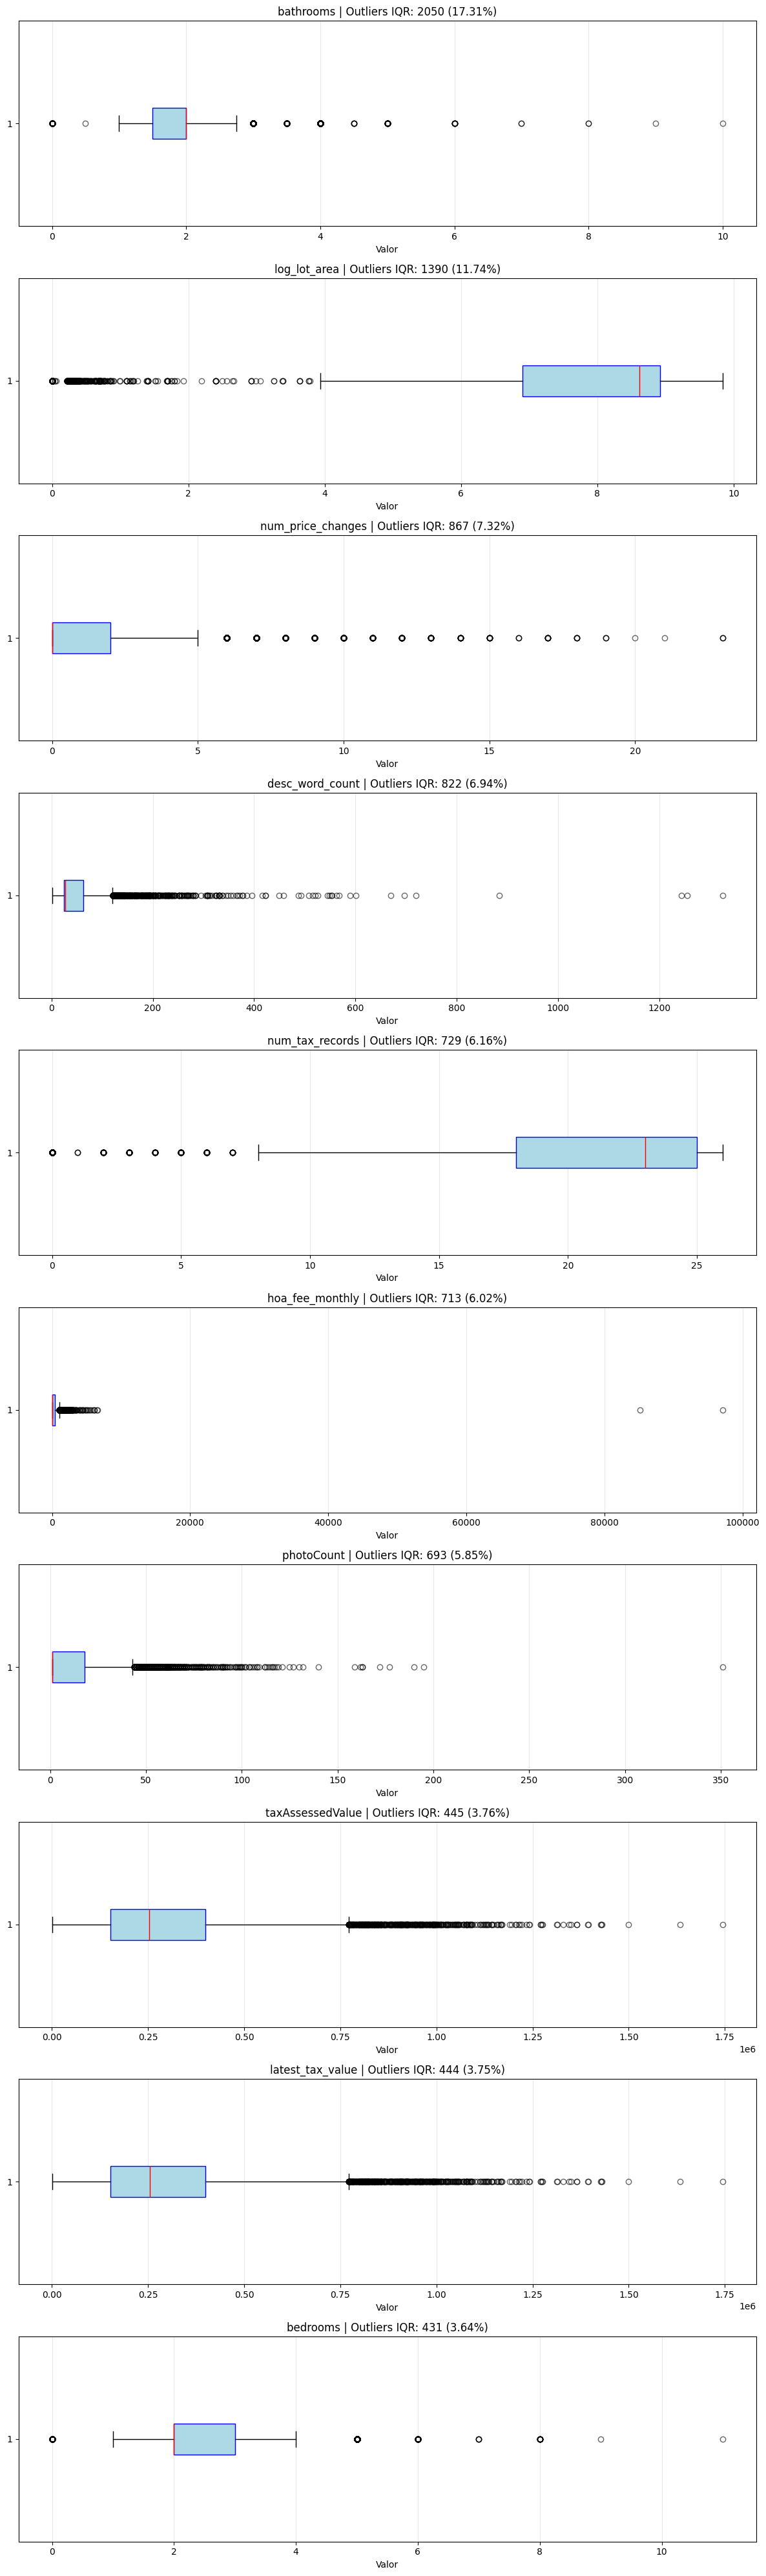

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar datos
df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - UCA\Documentos\participantt\data\tabular\train_processed.csv", low_memory=False)

# 2. Seleccionar solo columnas numéricas y limpiar
numeric_cols = df.select_dtypes(include=['number']).columns
df_num = df[numeric_cols].copy()
df_num = df_num.loc[:, df_num.notna().any()]       # Eliminar columnas 100% nulas
df_num = df_num.loc[:, df_num.var() != 0]          # Eliminar columnas con varianza 0

# 3. 🔍 IDENTIFICAR Y EXCLUIR VARIABLES BINARIAS AUTOMÁTICAMENTE
# Una variable es binaria si, ignorando NaNs, solo contiene exactamente los valores 0 y 1
binary_cols = [col for col in df_num.columns 
               if df_num[col].dropna().nunique() == 2 and 
                  df_num[col].dropna().isin([0, 1]).all()]

print(f"🚫 Variables binarias detectadas y excluidas del análisis: {len(binary_cols)}")
print(f"   -> {binary_cols}\n")

df_continuous = df_num.drop(columns=binary_cols)

# 4. Método IQR (solo continuas)
def detect_iqr(df):
    outliers_iqr = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (df[col] < lower) | (df[col] > upper)
        outliers_iqr[col] = df[mask]
    return outliers_iqr

# 5. Método Z-Score CORREGIDO (solo continuas)
def detect_zscore(df, threshold=3.0):
    outliers_z = {}
    for col in df.columns:
        serie = df[col].dropna()
        if serie.empty:
            outliers_z[col] = pd.DataFrame()
            continue
        # Aplicar log1p si es positiva y altamente sesgada (típico en precios/áreas)
        if serie.min() > 0 and (serie.max() / serie.median()) > 10:
            z_vals = np.abs(stats.zscore(np.log1p(serie)))
        else:
            z_vals = np.abs(stats.zscore(serie))
            
        mask = pd.Series(z_vals > threshold, index=serie.index)
        mask = mask.reindex(df.index, fill_value=False)
        outliers_z[col] = df[mask]
    return outliers_z

# 6. Ejecutar detección SOLO en variables continuas
out_iqr = detect_iqr(df_continuous)
out_z   = detect_zscore(df_continuous, threshold=3.0)

# 7. 📊 GENERAR REPORTE COMO DATAFRAME
total_registros = len(df_continuous)
reporte_list = []

for col in df_continuous.columns:
    n_iqr = len(out_iqr[col])
    n_z   = len(out_z[col])
    reporte_list.append({
        'Variable': col,
        'Total_Filas': total_registros,
        'Outliers_IQR': n_iqr,
        '%_IQR': round((n_iqr / total_registros) * 100, 2),
        'Outliers_ZScore': n_z,
        '%_ZScore': round((n_z / total_registros) * 100, 2)
    })

df_report = pd.DataFrame(reporte_list)
# Ordenar descendente por cantidad de outliers (IQR)
df_report = df_report.sort_values(by='Outliers_IQR', ascending=False).reset_index(drop=True)

print("📊 REPORTE DE OUTLIERS DETECTADOS (Solo Variables Continuas):")
print(df_report.to_string(index=False))

# 💡 Si usas Jupyter/Colab, descomenta para mejor visualización:
# display(df_report)

## Exportar a CSV
#df_report.to_csv('reporte_outliers.csv', index=False, sep=';')
#print("\n✅ Reporte guardado como 'reporte_outliers.csv'")

## 8. Visualización (Top 10 columnas continuas con más outliers)
#cols_to_plot = df_report['Variable'].head(10).tolist()
#if cols_to_plot:
#    plt.figure(figsize=(14, 6))
#    df_continuous[cols_to_plot].boxplot(grid=False, vert=False, fontsize=10)
#    plt.title("Top 10 columnas continuas con mayor cantidad de outliers (Método IQR)")
#    plt.tight_layout()
#    plt.show()
#else:
#    print("No se encontraron columnas continuas para graficar.")



# 7. 📊 GENERAR REPORTE COMO DATAFRAME (mejorado con estadísticas)
total_registros = len(df_continuous)
reporte_list = []

for col in df_continuous.columns:
    n_iqr = len(out_iqr[col])
    n_z   = len(out_z[col])
    reporte_list.append({
        'Variable': col,
        'Total_Filas': total_registros,
        'Outliers_IQR': n_iqr,
        '%_IQR': round((n_iqr / total_registros) * 100, 2),
        'Outliers_ZScore': n_z,
        '%_ZScore': round((n_z / total_registros) * 100, 2),
        # Estadísticas descriptivas para contexto
        'Media': round(df_continuous[col].mean(), 2),
        'Mediana': round(df_continuous[col].median(), 2),
        'Min': round(df_continuous[col].min(), 2),
        'Max': round(df_continuous[col].max(), 2),
        'Q1': round(df_continuous[col].quantile(0.25), 2),
        'Q3': round(df_continuous[col].quantile(0.75), 2)
    })

df_report = pd.DataFrame(reporte_list)
df_report = df_report.sort_values(by='Outliers_IQR', ascending=False).reset_index(drop=True)

print("📊 REPORTE DE OUTLIERS DETECTADOS (Solo Variables Continuas):")
print(df_report.to_string(index=False))

# Exportar a CSV
df_report.to_csv('reporte_outliers.csv', index=False, sep=';')
print("\n✅ Reporte guardado como 'reporte_outliers.csv'")

# 8. 📈 VISUALIZACIÓN MEJORADA: Subplots con escalas independientes
cols_to_plot = df_report['Variable'].head(10).tolist()

if cols_to_plot:
    fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 4*len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = [axes]  # Asegurar que sea iterable
    
    for ax, col in zip(axes, cols_to_plot):
        # Boxplot individual con escala propia
        ax.boxplot(df_continuous[col].dropna(), vert=False, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red'),
                   flierprops=dict(marker='o', color='orange', alpha=0.6))
        ax.set_title(f"{col} | Outliers IQR: {df_report[df_report['Variable']==col]['Outliers_IQR'].values[0]} ({df_report[df_report['Variable']==col]['%_IQR'].values[0]}%)")
        ax.set_xlabel('Valor')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Opcional: Guardar la figura
    # plt.savefig('outliers_boxplots.png', dpi=300, bbox_inches='tight')
else:
    print("No se encontraron columnas continuas para graficar.")